In [1]:
import numpy as np
import pandas as pd
import random
# load et simulation function from simulate_population.py: 
from simulate_population import sim_population
import torch
import torch.nn as nn

## 0) Simulate the data and test set (df_short and df_test)

In [76]:
# simulate data 
horizon = 10
pop = sim_population(N=20000, step_forward=horizon, randomseed=42+5)
df_short = pop.history[0].copy()
events = ["a", "b", "c","d","e"]
for e in events:
    df_short[f"time_{e}"] = df_short[f"time_{e}"].fillna(horizon)
    df_short[f"time_{e}"] = np.minimum(horizon, df_short[f"time_{e}"].fillna(horizon))

In [78]:
# simulate test data
pop_test = sim_population(N=5000, step_forward=horizon, randomseed=42+100)
df_test = pop_test.history[0].copy()
for e in events:
    df_test[f"time_{e}"] = df_test[f"time_{e}"].fillna(horizon)
    df_test[f"time_{e}"] = np.minimum(horizon, df_test[f"time_{e}"].fillna(horizon))

In [80]:
# concordance index calculations
from lifelines.utils import concordance_index
def get_cindex_for_event(predictions, df = df_short, event = "b"):
    time_col = f"time_{event}"
    risk_col = f"event_{event}"
    c = concordance_index(df[time_col], predictions, df[risk_col])
    return(c)

In [82]:
# X -> g(X, t, no time-varying covariates) -> g(X) * g0(t) <=> proportional hazards PH 
# time = age , but not a positional (same as in Delphi-2m), it is a context 
# binary outcomes t0 -> t1 , from age0 -> age1 
# batch should be stratified by outcome
# x-> FFW -> FFW -> fit a normal Cox Model to the embedding -> compute c-index -> update FFW weights ?
# This way we found embedding for the initial features, and fit a Cox model-> very transparent 
# multi-outcome: cause-specific Cox models for each variable 

# x → NN → single risk score -> minimize Cox loss


In [87]:
e = "c"
time_col = f"time_{e}"
event_col = f"event_{e}"

## CoxNN in pytorch

In [91]:
class CoxNN(nn.Module):
    def __init__(self, p, hidden_dims=(64, 32)):
        super().__init__()
        layers = []
        in_dim = p
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))  # scalar risk score
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)  # shape (n,)

# This is the same as 
#class CoxNN(nn.Module):
#    def __init__(self, p, hidden_dims = [64,32]):
#        super().__init__()
#        self.fc1 = nn.Linear(p, hidden_dims[0])
#        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
#        self.out = nn.Linear(hidden_dims[1], 1)  # scalar risk score#
#    def forward(self, x):
#        x = self.fc1(x)
#        x = F.relu(x)#
#        x = self.fc2(x)
#        x = F.relu(x)
#        x = self.out(x)
#        return x.squeeze(-1)  # shape (n,)

In [189]:
def cox_partial_loglik(eta, time, event):
    """ eta: (n,) risk scores;     time: (n,) observed times;     event: (n,) 1 if event, 0 if censored """
    # sort by decreasing time
    order = torch.argsort(time, descending=True)
    eta = eta[order]
    event = event[order]
    # log cumulative sum of exp(eta)
    log_cumsum_exp = torch.logcumsumexp(eta, dim=0)
    # 3. contribution only from observed events
    loglik = eta[event == 1] - log_cumsum_exp[event == 1]
    return -loglik.sum()

In [163]:
def train_cox(x, time, event, p=5, hidden_dims = ()):
    model = CoxNN(p=5, hidden_dims = hidden_dims)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   
    epochs = 1000
    for epoch in range(epochs):
        optimizer.zero_grad()
        eta = model(x)                     # risk scores
        loss = cox_partial_loglik(eta, time, event)
        loss.backward()
        optimizer.step()
        if ((epoch % 200 == 0)|(epoch +1 == epochs)):
            print(f"Epoch {epoch}, loss = {loss.item():.4f}")
    return (model)

In [97]:
# prepare the data 
covariate_cols = ["age_start", "bmi", "hyp", "sex", "eth"]
x = torch.tensor( df_short[covariate_cols].values, dtype=torch.float32)
time = torch.tensor( df_short[time_col].values, dtype=torch.float32)
event = torch.tensor(df_short[event_col].values, dtype=torch.float32)


## a) CoxNN with no layers

In [100]:
# Checking that this gives usual Cox estimates with hidden_dims ==0
# coxn0 = CoxNN(p=5, hidden_dims = ())

In [102]:
coxn0 = train_cox(x,time,event, hidden_dims= ())

Epoch 0, loss = 161739.8438
Epoch 200, loss = 125125.3281
Epoch 400, loss = 124423.9844
Epoch 600, loss = 124359.5469
Epoch 800, loss = 124342.7891
Epoch 999, loss = 124339.1875


In [103]:
#After training:
#• eta = model(x) is the estimated log-risk
#• exp(eta) gives relative hazard
#• ordering of eta defines the risk ranking
#• no baseline hazard is estimated

## b) CoxNN with (16,16) layers

In [105]:
# Train a "real" CoxNN with hidden layers for encoding the covariates 
coxn = train_cox(x,time,event, hidden_dims= (16,16))

Epoch 0, loss = 124401.8750
Epoch 200, loss = 123683.2578
Epoch 400, loss = 122641.7969
Epoch 600, loss = 122617.4531
Epoch 800, loss = 122605.1250
Epoch 999, loss = 122600.7891


## c) CoxPH from Lifelines:

In [107]:
from lifelines import CoxPHFitter
cph = CoxPHFitter()
cph.fit(df_short[[time_col, event_col] + covariate_cols], duration_col=time_col, event_col=event_col)
s=cph.summary[['coef', 'se(coef)', 'p']]
beta_cox = cph.params_.values
#print( beta_cox)
#round(s,4)

## Comparison for CoxPH and CoxNN

In [109]:
# compute log-hazards from CoxPH 
risk1 = cph.predict_log_partial_hazard(df_test[covariate_cols])

In [110]:
# compute log-hazards from CoxNN
x_test = torch.tensor( df_test[covariate_cols].values, dtype=torch.float32)
risk2 = coxn0(x_test).detach().numpy() 

*--- Risk from CoxPH (x) and CoxNN_zero (y)---*


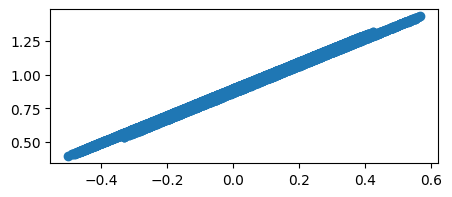

In [113]:
# plot one vs the other - should be the same 
import matplotlib.pyplot as plt
print ("*--- Risk from CoxPH (x) and CoxNN_zero (y)---*")
plt.figure(figsize = (5,2))
plt.scatter(risk1, risk2)

In [114]:
risk3 = coxn(x_test).detach().numpy() 

*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*


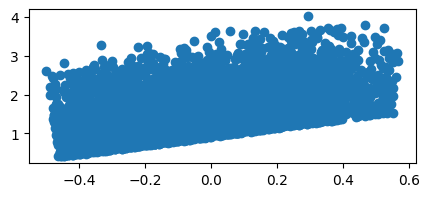

In [115]:
print ("*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*")
plt.figure(figsize = (5,2))
plt.scatter(risk1, risk3)

In [116]:
# compute c-index and betas from CoxPH and CoxNN
#  coxn0: 
# the model CoxNN with hidden_dim=() reduces to exactly one layer nn.Linear(p, 1)
#• weights of shape (1, p)
#• bias enabled by default
# That bias is the only deviation from a standard CoxPH.
#• beta_nn corresponds to the Cox coefficients
#• bias_nn should ideally be ~0 (but shouldn’t exist in Cox)
# --cindex 
c1 = get_cindex_for_event(risk1*(-1), df= df_test, event= e)
c2 = get_cindex_for_event(risk2*(-1), df= df_test, event= e)
c3 = get_cindex_for_event(risk3*(-1), df= df_test, event= e)
# betas 
linear_layer = coxn0.net[0]
beta_nn = linear_layer.weight.detach().cpu().numpy().flatten()
bias_nn = linear_layer.bias.detach().cpu().numpy()

In [118]:
# Display results - diff between training Cox Loss in NN and CoxPH in lifelines

[ 0.01502657 -0.01563892  0.12602514 -0.00135652  0.00179165]
[ 0.01503742 -0.01576607  0.1505299  -0.00110288  0.00308914]
C_index for df_test: [0.5726  0.57253 0.65052]


C:\Users\dinab\AppData\Local\Temp\ipykernel_1792\3091014872.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5725286607054806' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  res.loc["Cindex", :] =  [c1, c2, c3, np.nan]


,coef,CoxNN_0,CoxNN_1,ratio
covariate,,,,
age_start,0.015,0.015,NaN,1.001
bmi,-0.016,-0.016,NaN,1.008
hyp,0.151,0.126,NaN,1.194
sex,-0.001,-0.001,NaN,0.813
eth,0.003,0.002,NaN,1.724
Cindex,0.573,0.573,0.651,NaN


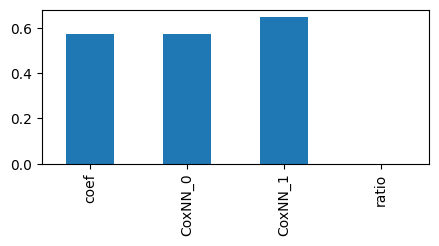

In [119]:
print(beta_nn)
print(beta_cox)
res = cph.summary[['coef']]
res["CoxNN_0"] = beta_nn
res["CoxNN_1"] = np.nan
res["ratio"] = res.coef / res.CoxNN_0
res.loc["Cindex", :] =  [c1, c2, c3, np.nan]

res.loc["Cindex", :].plot.bar(figsize = (5,2))

print("C_index for df_test:", np.round([c1, c2, c3], 5))
np.round(res,3)

## All in one go

In [225]:
def check_outcome (hidden_dims= (16,16), e = "a"):
    
    models = [] 
    
    time_col = f"time_{e}"
    event_col = f"event_{e}"
    covariate_cols = ["age_start", "bmi", "hyp", "sex", "eth"]
    x = torch.tensor( df_short[covariate_cols].values, dtype=torch.float32)
    time = torch.tensor( df_short[time_col].values, dtype=torch.float32)
    event = torch.tensor(df_short[event_col].values, dtype=torch.float32)
    # 1
    cph = CoxPHFitter()
    cph.fit(df_short[[time_col, event_col] + covariate_cols], duration_col=time_col, event_col=event_col)
    #s=cph.summary[['coef', 'se(coef)', 'p']]
    beta_cox = cph.params_.values
   
    # 2
    cox0 = train_cox(x,time,event, hidden_dims= ())
    linear_layer = coxn0.net[0]
    beta_nn = linear_layer.weight.detach().cpu().numpy().flatten()
    bias_nn = linear_layer.bias.detach().cpu().numpy()
    # 3
    coxn = train_cox(x,time,event, hidden_dims= hidden_dims)
    
    # --cindex 
    risk1 = cph.predict_log_partial_hazard(df_test[covariate_cols])
    risk2 = cox0(x_test).detach().numpy() 
    risk3 = coxn(x_test).detach().numpy() 
    c1 = get_cindex_for_event(risk1*(-1), df= df_test, event= e)
    c2 = get_cindex_for_event(risk2*(-1), df= df_test, event= e)
    c3 = get_cindex_for_event(risk3*(-1), df= df_test, event= e)

    # res
    res = cph.summary[['coef']]
    res["CoxNN_0"] = beta_nn
    res["CoxNN_1"] = np.nan
    res.loc["Cindex", :] =  [c1, c2, c3]
    #res.loc["Cindex", :].plot.bar(figsize = (5,2))

    print("Event:", e, "\nC_index for df_test:", np.round([c1, c2, c3], 5))
    print ("*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*")
    plt.figure(figsize = (5,2))
    plt.scatter(risk1, risk3)

    models.append(cph)
    models.append(cox0)
    models.append(coxn)
    
    return models, res
 

a
Epoch 0, loss = 255974.5781
Epoch 200, loss = 177350.4375
Epoch 400, loss = 134693.4062
Epoch 600, loss = 131653.9531
Epoch 800, loss = 131020.1328
Epoch 999, loss = 130648.9062
Epoch 0, loss = 133699.5312
Epoch 200, loss = 130200.6094
Epoch 400, loss = 130188.9531
Epoch 600, loss = 130188.9062
Epoch 800, loss = 130188.9062
Epoch 999, loss = 130188.8906


C:\Users\dinab\AppData\Local\Temp\ipykernel_1792\2970067118.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6981033001249745' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  res.loc["Cindex", :] =  [c1, c2, c3]


Event: a 
C_index for df_test: [0.70377 0.6981  0.70377]
*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*
b
Epoch 0, loss = 184669.7344
Epoch 200, loss = 138022.5156
Epoch 400, loss = 131251.5000
Epoch 600, loss = 131069.6016
Epoch 800, loss = 130953.4922
Epoch 999, loss = 130882.1094
Epoch 0, loss = 132253.9219
Epoch 200, loss = 129611.3125
Epoch 400, loss = 128598.6016
Epoch 600, loss = 128551.1250
Epoch 800, loss = 128363.6719
Epoch 999, loss = 128168.3750
Event: b 
C_index for df_test: [0.63299 0.63055 0.7062 ]
*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*
c


C:\Users\dinab\AppData\Local\Temp\ipykernel_1792\2970067118.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6305486208875575' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  res.loc["Cindex", :] =  [c1, c2, c3]


Epoch 0, loss = 220208.5000
Epoch 200, loss = 161264.5938
Epoch 400, loss = 126442.6875
Epoch 600, loss = 124346.1094
Epoch 800, loss = 124338.8750
Epoch 999, loss = 124338.5391
Epoch 0, loss = 125227.6328
Epoch 200, loss = 123181.4688
Epoch 400, loss = 122455.1094
Epoch 600, loss = 122350.0859
Epoch 800, loss = 122314.2344
Epoch 999, loss = 122266.4922
Event: c 
C_index for df_test: [0.5726  0.57264 0.65803]
*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*
d


C:\Users\dinab\AppData\Local\Temp\ipykernel_1792\2970067118.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5726417704843085' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  res.loc["Cindex", :] =  [c1, c2, c3]


Epoch 0, loss = 36863.2773
Epoch 200, loss = 27104.3340
Epoch 400, loss = 23065.9688
Epoch 600, loss = 23001.2930
Epoch 800, loss = 23001.2461
Epoch 999, loss = 23001.2500
Epoch 0, loss = 23044.7773
Epoch 200, loss = 23000.0918
Epoch 400, loss = 22998.6992
Epoch 600, loss = 22967.2559
Epoch 800, loss = 22957.0117
Epoch 999, loss = 22952.7871
Event: d 
C_index for df_test: [0.55997 0.55998 0.5655 ]
*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*
e


C:\Users\dinab\AppData\Local\Temp\ipykernel_1792\2970067118.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.559976201021184' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  res.loc["Cindex", :] =  [c1, c2, c3]


Epoch 0, loss = 24313.3594
Epoch 200, loss = 22563.2539
Epoch 400, loss = 22521.4727
Epoch 600, loss = 22513.9297
Epoch 800, loss = 22513.0234
Epoch 999, loss = 22512.9531
Epoch 0, loss = 22656.7207
Epoch 200, loss = 22518.7305
Epoch 400, loss = 22505.1113
Epoch 600, loss = 22496.9375
Epoch 800, loss = 22490.8574
Epoch 999, loss = 22487.5586
Event: e 
C_index for df_test: [0.55857 0.55858 0.56484]
*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*


C:\Users\dinab\AppData\Local\Temp\ipykernel_1792\2970067118.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5585789244496717' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  res.loc["Cindex", :] =  [c1, c2, c3]


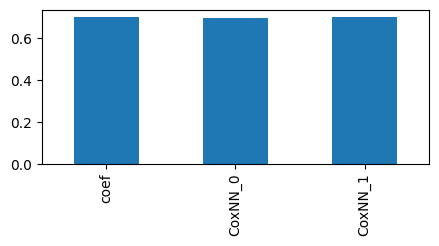

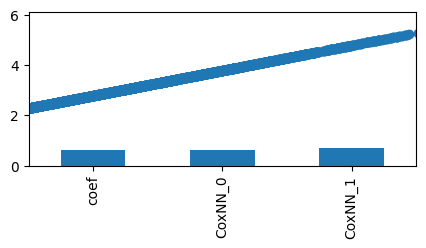

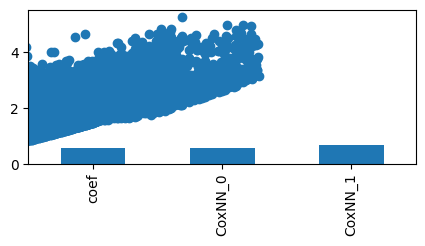

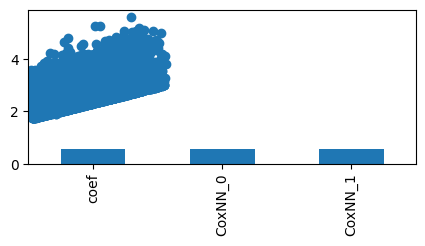

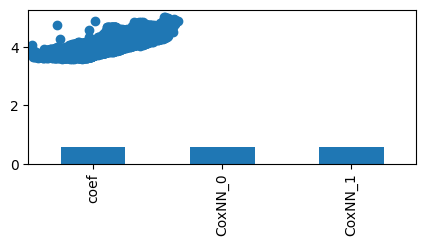

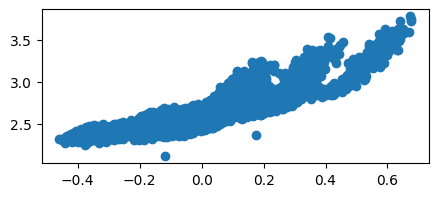

In [221]:
# we will run the above function for each event one by one 
# store all the models (cox, coxm0 and coxnn in models for each event)
# models [outcome number 0-"a", ... 3-"e"][model number 0-coxph, 1-coxn0, 2-coxnn]
res = []
models = []
for e in ["a", "b", "c", "d", "e"]:
    print(e)
    model_e, res_e = check_outcome (hidden_dims= (16,16), e = e)
    res.append(res_e)
    models.append(model_e)
    

In [237]:
models[1][1]

CoxNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [239]:
rows = []
for i, event in enumerate(events):
    df_i = res[i].loc[["Cindex"]].copy()   # keep as DataFrame
    df_i["event"] = event
    rows.append(df_i)
out = pd.concat(rows, ignore_index=True)

## Results

<Axes: xlabel='event'>

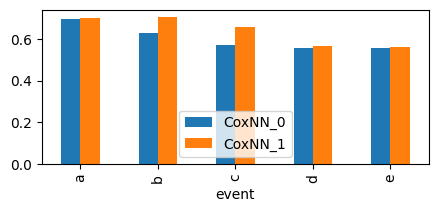

In [241]:
out.set_index("event").iloc[:, 1:3].plot.bar(figsize = (5,2))

In [243]:
out

,coef,CoxNN_0,CoxNN_1,event
0,0.703775,0.698103,0.703775,a
1,0.632990,0.630549,0.706199,b
2,0.572601,0.572642,0.658027,c
3,0.559971,0.559976,0.565500,d
4,0.558570,0.558579,0.564835,e


## Multi-outcome CoxNN

In [169]:
#By default, nn.Linear(in_dim, K) includes a bias term (one per outcome).
#Just like in the single-outcome Cox case:
#the bias cancels out in the partial likelihood
#but it’s cleaner and more identifiable to remove it

# K - number of events (K outcomes)
class MultiCoxNN(nn.Module):
    def __init__(self, p, hidden_dims=(64, 32), K=5):
        super().__init__()
        layers = []
        in_dim = p
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, K,bias=False))  #  risk score for each of the K outcomes
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)  # shape (n,k)

*What it is*:
K independent cause-specific Cox models sharing all hidden layers and trained jointly; borrowing strength across outcomes.

*What it is not*: a competing-risks softmax model, a Fine–Gray model, a joint likelihood over mutually exclusive events.

In [179]:
# prepare the data for multi-outcome
covariate_cols = ["age_start", "bmi", "hyp", "sex", "eth"]
time_cols = ["time_a", "time_b", "time_c", "time_d","time_e"]
event_cols = ["event_a", "event_b", "event_c", "event_d","event_e"]
x2 = torch.tensor( df_short[covariate_cols].values, dtype=torch.float32)
time2 = torch.tensor( df_short[time_cols].values, dtype=torch.float32)
event2 = torch.tensor(df_short[event_cols].values, dtype=torch.float32)


In [209]:
def train_coxmulti(x2, time2, event2, p=5, hidden_dims = (), epochs = 1000):
    # p -number of initial params, len(covariate_cols)
    model = MultiCoxNN(p=p, K=K, hidden_dims = hidden_dims)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)   
    for epoch in range(epochs):
        optimizer.zero_grad()
        eta2 = model(x)                     # risk scores
        loss = 0
        for k in range(K):
            loss += cox_partial_loglik(
            eta2[:, k],
            time2[:, k],
            event2[:, k])
        loss = loss / K
        loss.backward()
        optimizer.step()
        if ((epoch % 200 == 0)|(epoch +1 == epochs)):
            print(f"Epoch {epoch}, loss = {loss.item():.4f}")
    return (model)

### Train the multicox models, empty and actual one 

In [205]:
coxmmulti_null = train_coxmulti(x2, time2, event2, p=5, hidden_dims = ())

Epoch 0, loss = 129855.4609
Epoch 200, loss = 86171.2656
Epoch 400, loss = 86170.9453
Epoch 600, loss = 86170.9453
Epoch 800, loss = 86170.9453
Epoch 999, loss = 86170.9453


In [211]:
coxmmulti = train_coxmulti(x2, time2, event2, p=5, hidden_dims = (64,64))

Epoch 0, loss = 88201.2891
Epoch 200, loss = 85345.0469
Epoch 400, loss = 85244.7266
Epoch 600, loss = 85145.4922
Epoch 800, loss = 85132.2188
Epoch 999, loss = 85131.9766


In [217]:
coxmmulti_null(x)[0,:]

tensor([2.2671, 1.7304, 0.9434, 1.0057, 0.9217], grad_fn=<SelectBackward0>)

## Compare the models - multi with one event

In [295]:
## We will compare the cindex and correlation of the predictions for the df_test 

def corr_with_coxph(risk, risk_coxph):
    return np.corrcoef(risk, risk_coxph)[0, 1]

def evaluate_all_models_cindex(    models,    coxmmulti_null,    coxmmulti,  
                               df_test,    covariate_cols,    time_cols,    event_cols,    events):
    """
    models[outcome][model]:
        model 0 = CoxPH
        model 1 = CoxNN_00
        model 2 = CoxNN_(64,64)
    """
    x_test = torch.tensor(        df_test[covariate_cols].values,        dtype=torch.float32    )
    rows = []
    corr_rows=[]
    # evaluate multi-output models once
    with torch.no_grad():
        risk_multi_null = coxmmulti_null(x_test).numpy()
        risk_multi      = coxmmulti(x_test).numpy()

    for k, e in enumerate(events):
        time_col  = time_cols[k]
        event_col = event_cols[k]
        # ---- single-event models ----
        cph   = models[k][0]
        coxn0 = models[k][1]
        coxn  = models[k][2]
        risk_cph = cph.predict_log_partial_hazard(df_test[covariate_cols]).values
        with torch.no_grad():
            risk_coxn0 = coxn0(x_test).numpy().squeeze()
            risk_coxn  = coxn(x_test).numpy().squeeze()
        row = {
            "event": e,
            "CoxPH": get_cindex_for_event( -risk_cph, df_test, e),
            "CoxNN_00": get_cindex_for_event( -risk_coxn0, df_test, e),
            "CoxNN_Real": get_cindex_for_event(-risk_coxn, df_test, e),
            "MultiCoxNN_00": get_cindex_for_event(-risk_multi_null[:, k], df_test, e),
            "MultiCoxNN_Real": get_cindex_for_event(-risk_multi[:, k], df_test, e),
        }
        rows.append(row)

        # ---------- correlation w/ CoxPH ----------
        corr_rows.append({
            "event": e,
            "CoxPH": 1.0,  # self-correlation
            "CoxNN_00": corr_with_coxph( risk_coxn0, risk_cph           ),
            "CoxNN_Real": corr_with_coxph(                risk_coxn, risk_cph            ),
            "MultiCoxNN_00": corr_with_coxph(                risk_multi_null[:, k], risk_cph           ),
            "MultiCoxNN_Real": corr_with_coxph(                risk_multi[:, k], risk_cph            ),
        })
        
    cindex_df = pd.DataFrame(rows).set_index("event")
    corr_df = pd.DataFrame(corr_rows).set_index("event")
    
    return cindex_df, corr_df


In [278]:
cindex_results, corr_results = evaluate_all_models_cindex( models,    coxmmulti_null,    coxmmulti,    df_test,     covariate_cols,    time_cols,    event_cols,    events)

## Results 

In [280]:
cindex_results.T

event,a,b,c,d,e
CoxPH,0.703775,0.632990,0.572601,0.559971,0.558570
CoxNN_00,0.698103,0.630549,0.572642,0.559976,0.558579
CoxNN_Real,0.703775,0.706199,0.658027,0.565500,0.564835
MultiCoxNN_00,0.703774,0.632990,0.572601,0.559971,0.558569
MultiCoxNN_Real,0.703982,0.711160,0.659369,0.559799,0.566561


In [282]:
corr_results.T

event,a,b,c,d,e
CoxPH,1.000000,1.000000,1.000000,1.000000,1.000000
CoxNN_00,0.968364,0.984911,0.999984,1.000000,0.999988
CoxNN_Real,1.000000,0.678443,0.466674,0.750789,0.875588
MultiCoxNN_00,1.000000,1.000000,1.000000,1.000000,1.000000
MultiCoxNN_Real,0.999446,0.677401,0.457247,0.785650,0.880937


<Axes: xlabel='event'>

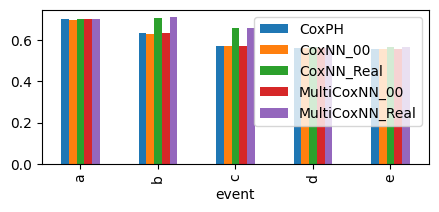

In [292]:
cindex_results.plot.bar(figsize = (5,2))

## Now in binary format 